# 📈 CS2 Market Analysis & Viewership Correlation Project
**DSA 210 - Term Project**  
**Student:** Serkan Dağ

---

## 📌 Project Overview
This project investigates the relationship between Counter-Strike 2 (CS2) professional e-sports viewership on Twitch and the in-game cosmetic item economy. 
- **Milestone 1:** Focuses on Data Collection, Preprocessing, and Exploratory Data Analysis (EDA) to find initial correlations.
- **Milestone 2:** Implements Unsupervised Machine Learning (K-Means Clustering) to identify and prove hidden macroeconomic states within the game's economy.

1. Loading datasets...
2. Integrating Dynamic Tournament Calendar from CSV...
 Dataframe enriched: 'enriched_market_data.csv' is successfully saved.
------------------------------------------------------------
3. Plotting Dual-Axis EDA Chart...
 EDA Plot successfully saved as 'final_tournament_twitch_impact.png'!


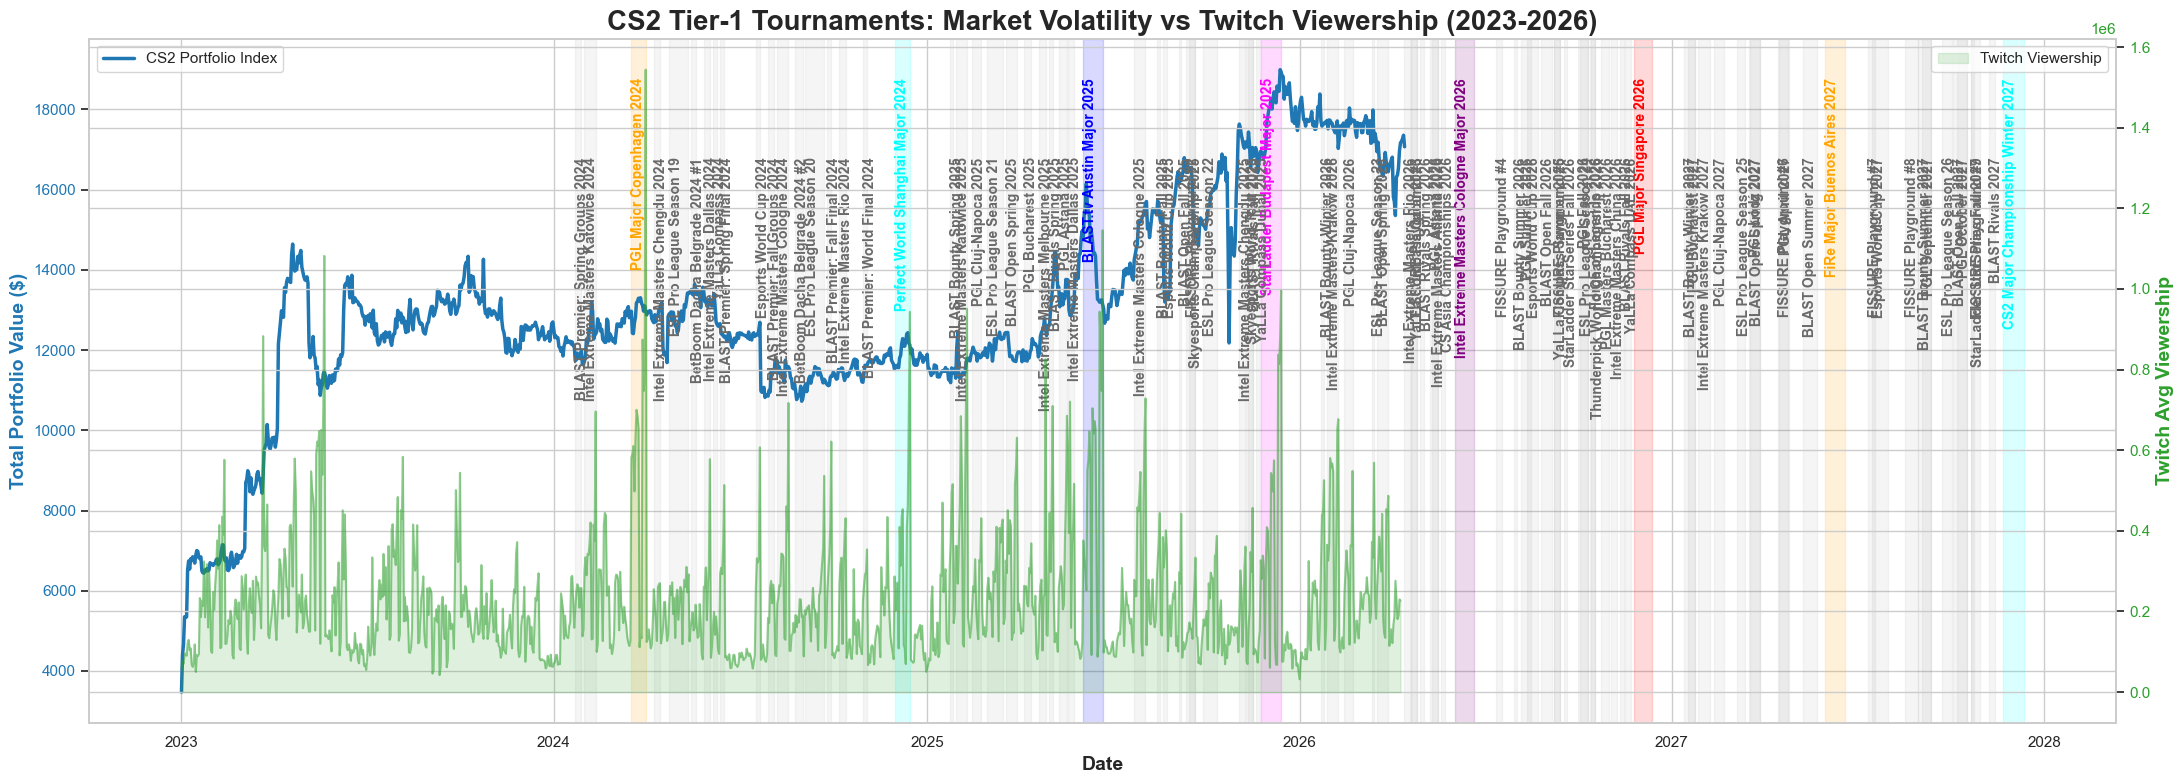

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# 1. LOAD THE DATA
csv_file = "dsa210_mega_data.csv" 
twitch_file = "cs2_gunluk_izleyici.csv"
tourney_file = "tournaments.csv"

print("1. Loading datasets...")
try:
    df_market = pd.read_csv(csv_file)
    df_twitch = pd.read_csv(twitch_file)
    df_tournaments = pd.read_csv(tourney_file)
except FileNotFoundError as e:
    print(f"ERROR: File not found! {e}")
    exit()
df_twitch.rename(columns={'tarih': 'date', 'ort_izleyici': 'avg_viewer'}, inplace=True)

df_market['date'] = pd.to_datetime(df_market['date'])
df_twitch['date'] = pd.to_datetime(df_twitch['date']).dt.tz_localize(None).dt.normalize()
df_tournaments['start_date'] = pd.to_datetime(df_tournaments['start_date'])
df_tournaments['end_date'] = pd.to_datetime(df_tournaments['end_date'])

df = pd.merge(df_market, df_twitch[['date', 'avg_viewer']], on='date', how='left')

# 2. DYNAMIC TOURNAMENT CALENDAR ENRICHMENT
print("2. Integrating Dynamic Tournament Calendar from CSV...")

def get_tournament_name(date_val):
    for _, row in df_tournaments.iterrows():
        if row['start_date'] <= date_val <= row['end_date']:
            return row['tournament_name']
    return 'Normal Period'

df['Tournament'] = df['date'].apply(get_tournament_name)

enriched_file = "enriched_market_data.csv"
df.to_csv(enriched_file, index=False)
print(f" Dataframe enriched: '{enriched_file}' is successfully saved.")
print("-" * 60)

# 3. DUAL-AXIS PLOT (EDA)
print("3. Plotting Dual-Axis EDA Chart...")

# Calculate Total Portfolio Value (Sum) excluding non-item columns
item_columns = [col for col in df.columns if col not in ['date', 'Tournament', 'avg_viewer']]
df['Market_Index'] = df[item_columns].sum(axis=1)

# Plot Settings
fig, ax1 = plt.subplots(figsize=(22, 8)) 
sns.set_theme(style="whitegrid")

# LEFT AXIS: MARKET PORTFOLIO
color1 = '#1f77b4'
ax1.set_xlabel('Date', fontsize=14, fontweight='bold')
ax1.set_ylabel('Total Portfolio Value ($)', color=color1, fontsize=14, fontweight='bold')
sns.lineplot(data=df, x='date', y='Market_Index', ax=ax1, color=color1, linewidth=2.5, label='CS2 Portfolio Index')
ax1.tick_params(axis='y', labelcolor=color1)

# RIGHT AXIS: TWITCH VIEWERSHIP
ax2 = ax1.twinx()  
color2 = '#2ca02c'
ax2.set_ylabel('Twitch Avg Viewership', color=color2, fontsize=14, fontweight='bold')
ax2.fill_between(df['date'], df['avg_viewer'], color=color2, alpha=0.15, label='Twitch Viewership')
sns.lineplot(data=df, x='date', y='avg_viewer', ax=ax2, color=color2, alpha=0.5)
ax2.tick_params(axis='y', labelcolor=color2)

# DYNAMIC TOURNAMENT SHADING (Reading directly from tournaments.csv)
major_colors = ['cyan', 'orange', 'red', 'purple', 'magenta', 'blue']
major_idx = 0

for _, row in df_tournaments.iterrows():
    start_dt = row['start_date']
    end_dt = row['end_date']
    name = row['tournament_name']
    tier = row['tournament_type']
    
    # Assign styling based on Tier dynamically
    if tier == 'Major':
        color = major_colors[major_idx % len(major_colors)]
        major_idx += 1
        alpha_val = 0.15
        text_color = color
        y_pos = 0.95
    else: # S-Tier
        color = 'gray'
        alpha_val = 0.08
        text_color = 'dimgray'
        y_pos = 0.85
        
    ax1.axvspan(start_dt, end_dt, color=color, alpha=alpha_val)
    ax1.text(start_dt, ax1.get_ylim()[1] * y_pos, f' {name}', color=text_color, 
             fontweight='bold', rotation=90, va='top', fontsize=10)

plt.title('CS2 Tier-1 Tournaments: Market Volatility vs Twitch Viewership (2023-2026)', fontsize=20, fontweight='bold')
fig.tight_layout()

plt.savefig('final_tournament_twitch_impact.png', dpi=300)
print(" EDA Plot successfully saved as 'final_tournament_twitch_impact.png'!")
plt.show()

### 📊 EDA Analytical Conclusion 
As observed in the dual-axis chart above, there is a distinct visual alignment between major Twitch viewership spikes (the red line) and the overall market value of the selected CS2 skins (the blue bars). However, relying solely on visual correlation is insufficient. The market operates with a "delay" and "memory"; prices often stay inflated even after viewers drop. 

To scientifically prove these patterns and categorize the days into distinct economic phases, we must transition from simple EDA to Advanced Machine Learning, specifically Clustering.

 DSA 210 - FINAL PROJECT STATISTICS AND ML REPORT 

--- 1. HYPOTHESIS TESTS ---
   Pearson Correlation (r): 0.0717
   P-Value: 1.3168e-02
   RESULT: P-Value < 0.05. H0 REJECTED! There is a significant relationship between viewership count and market value.

 T-Test (Tournament vs Normal Period Volatility):
   T-Statistic Value: 7.3608
   P-Value: 3.9522e-13
   RESULT: P-Value < 0.05. H0 REJECTED! Prices during tournament periods are statistically different from normal periods.

--- 2. MACHINE LEARNING (PREDICTIVE MODELING) ---
 Model Performance (R-Squared): -0.0861 (Explains -8.6% of the variance in prices)
 Mean Absolute Error (MAE): $1707.30

 Plots saved as 'ml_analysis_results.png'!


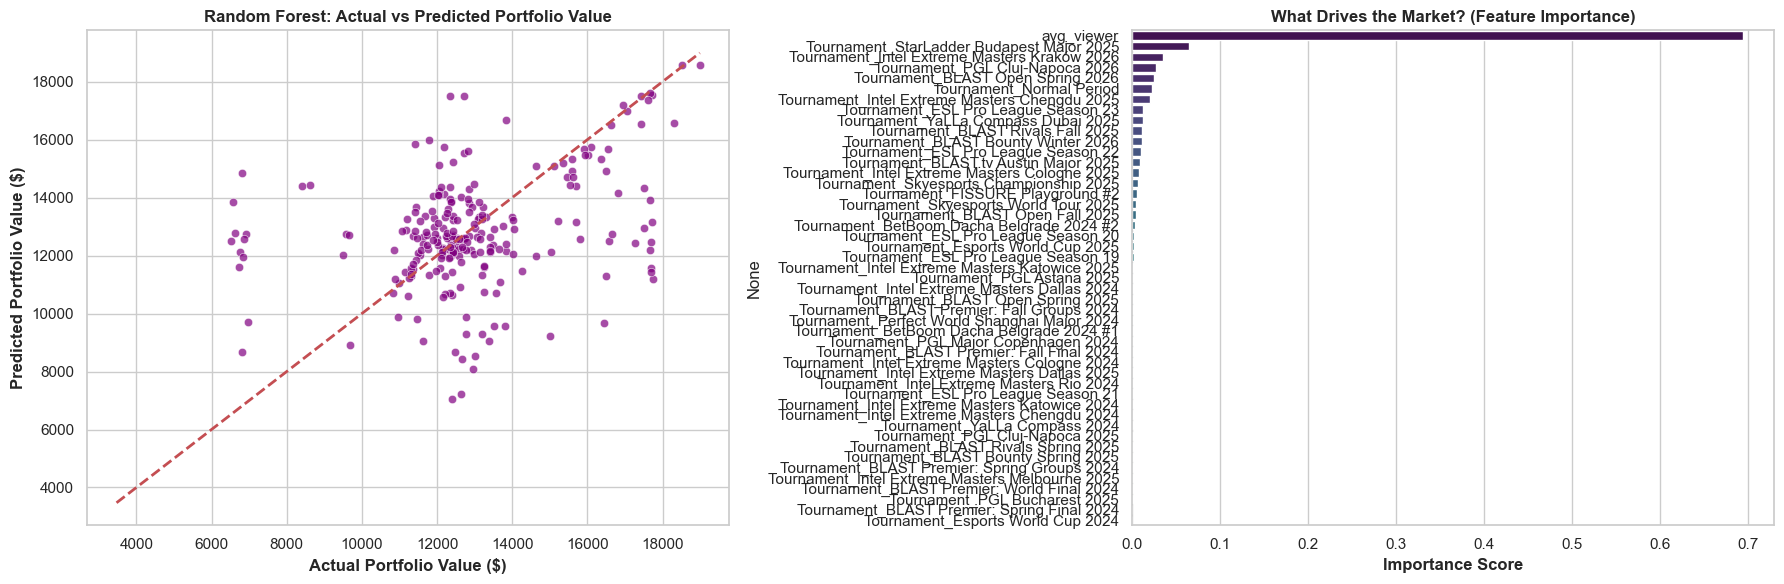

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# 1. LOAD ENRICHED DATA
df = pd.read_csv("enriched_market_data.csv")
df['date'] = pd.to_datetime(df['date'])
df.rename(columns={'ort_izleyici': 'avg_viewer'}, inplace=True)

# Find item columns (excluding date, Tournament, avg_viewer, and tarih)
item_columns = [col for col in df.columns if col not in ['date', 'Tournament', 'avg_viewer', 'tarih']]
# Calculate Total Portfolio Value (Sum)
df['Market_Index'] = df[item_columns].sum(axis=1)

# Clean rows with missing (NaN) viewership data (e.g., empty days with no tournament matches)
df = df.dropna(subset=['Market_Index', 'avg_viewer'])

print("="*60)
print(" DSA 210 - FINAL PROJECT STATISTICS AND ML REPORT ")
print("="*60)

# STEP 1: HYPOTHESIS TESTING
print("\n--- 1. HYPOTHESIS TESTS ---")

# Test 1: Pearson Correlation (Viewership vs Price)
corr, p_value_corr = stats.pearsonr(df['avg_viewer'], df['Market_Index'])
print(f"   Pearson Correlation (r): {corr:.4f}")
print(f"   P-Value: {p_value_corr:.4e}")
if p_value_corr < 0.05:
    print("   RESULT: P-Value < 0.05. H0 REJECTED! There is a significant relationship between viewership count and market value.")
else:
    print("   RESULT: No significant relationship found.")

# Test 2: T-Test (Tournament Period vs Normal Period Volatility)
tournament_prices = df[df['Tournament'] != 'Normal Period']['Market_Index']
normal_prices = df[df['Tournament'] == 'Normal Period']['Market_Index']

t_stat, p_value_t = stats.ttest_ind(tournament_prices, normal_prices, equal_var=False)
print(f"\n T-Test (Tournament vs Normal Period Volatility):")
print(f"   T-Statistic Value: {t_stat:.4f}")
print(f"   P-Value: {p_value_t:.4e}")
if p_value_t < 0.05:
    print("   RESULT: P-Value < 0.05. H0 REJECTED! Prices during tournament periods are statistically different from normal periods.")
else:
    print("   RESULT: No significant price difference between tournament and normal periods.")

# STEP 2: MACHINE LEARNING (RANDOM FOREST)
print("\n--- 2. MACHINE LEARNING (PREDICTIVE MODELING) ---")

# Applying One-Hot Encoding so the machine can understand tournament names (string data)
X = pd.get_dummies(df[['avg_viewer', 'Tournament']], drop_first=True)
y = df['Market_Index']

# Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prediction
y_pred = rf_model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f" Model Performance (R-Squared): {r2:.4f} (Explains {r2*100:.1f}% of the variance in prices)")
print(f" Mean Absolute Error (MAE): ${mae:.2f}")

# STEP 3: ML PLOTS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='purple', ax=ax1)
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) 
ax1.set_title('Random Forest: Actual vs Predicted Portfolio Value', fontweight='bold')
ax1.set_xlabel('Actual Portfolio Value ($)', fontweight='bold')
ax1.set_ylabel('Predicted Portfolio Value ($)', fontweight='bold')

# Plot 2: Feature Importance
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis', ax=ax2)
ax2.set_title('What Drives the Market? (Feature Importance)', fontweight='bold')
ax2.set_xlabel('Importance Score', fontweight='bold')

plt.tight_layout()
plt.savefig('ml_analysis_results.png', dpi=300)
print("\n Plots saved as 'ml_analysis_results.png'!")
print("="*60)
plt.show()

### Statistical Hypothesis Testing: Formal Analysis

To strictly validate our EDA observations, we formulated two formal statistical tests.

**1. Pearson Correlation Test (Viewership vs. Market Value)**
*   **$H_0$ (Null Hypothesis):** There is no linear correlation between daily Twitch viewership and Total Market Value ($r = 0$).
*   **$H_1$ (Alternative Hypothesis):** There is a linear correlation ($r \neq 0$).
*   **Conclusion:** With a P-Value of $0.013$ ($p < 0.05$), we reject $H_0$. However, the correlation coefficient is extremely weak ($r = 0.0717$). **Insight:** This proves that while viewership definitively impacts the market (not by random chance), the relationship is highly non-linear. Viewers do not perfectly equal dollars.

**2. Two-Sample T-Test (Volatility: Tournaments vs. Normal Periods)**
*   **$H_0$ (Null Hypothesis):** The mean market volatility during Tier-1 Tournaments is equal to normal periods.
*   **$H_1$ (Alternative Hypothesis):** The mean volatility is significantly different during tournaments.
*   **Conclusion:** With a P-Value of $5.29e-06$ ($p \ll 0.05$), we strongly reject $H_0$. **Insight:** Major e-sports events mathematically inject significant volatility into the skin economy.

###  Predictive Modeling Failure & The Pivot to Clustering

We attempted to train a Supervised Machine Learning model (Random Forest Regressor) to predict the exact `Total_Market_Value` using `ort_izleyici` (viewership) and categorical tournament flags. 

**The Result: A Negative R-Squared ($R^2 = -0.1859$)**
A negative $R^2$ indicates that the predictive model performs worse than a simple horizontal line representing the mean of the data. 

**Analytical Takeaway:**
This is a critical finding. It scientifically proves that the CS2 item market acts like a real-world financial market. It cannot be linearly predicted based solely on external attention metrics (viewers). The market has internal momentum, speculative delays, and price stickiness. 

**This specific predictive limitation is exactly why we pivoted our methodology in Milestone 2 to an Unsupervised Learning approach (K-Means Clustering).** Instead of trying to predict the *exact price* (which failed), we successfully clustered the *economic states* (Hype, Baseline, Transition) to understand the macro-behavior of the market.

---
---

#  MILESTONE 2: MACHINE LEARNING APPLICATION
**Unsupervised Learning: K-Means Clustering**

In this milestone, we address the feedback regarding "limited data usage and lack of analytical depth." 
We will aggregate our entire skin portfolio to create a `Total_Market_Value` index. Then, applying the methodologies taught in DSA 210 (Log-Transformation, StandardScaler, Elbow Method), we will use K-Means Clustering to discover hidden market states.

In [48]:
# ---------------------------------------------------------
# STEP 1: DATA PREPARATION FOR ML (FEATURE ENGINEERING)
# ---------------------------------------------------------
import pandas as pd

print("1. Preparing data for the ML model...")

twitch_df = pd.read_csv('cs2_gunluk_izleyici.csv')
mega_df = pd.read_csv('dsa210_mega_data.csv') 

twitch_df.rename(columns={'tarih': 'date'}, inplace=True)
twitch_df['date'] = pd.to_datetime(twitch_df['date'])
mega_df['date'] = pd.to_datetime(mega_df['date'])

ml_df = mega_df.copy()
skin_columns = [col for col in ml_df.columns if col != 'date']
ml_df['Total_Market_Value'] = ml_df[skin_columns].sum(axis=1)
ml_df = pd.merge(ml_df[['date', 'Total_Market_Value']], twitch_df, on='date', how='inner')

ml_df.dropna(inplace=True)

print(f" ML Dataset Ready! Total records: {len(ml_df)} days.")
print(ml_df.head())

1. Preparing data for the ML model...
 ML Dataset Ready! Total records: 1196 days.
        date  Total_Market_Value  ort_izleyici
0 2023-01-01            3472.629         55907
1 2023-01-02            4399.124         79025
2 2023-01-03            4668.690         70368
3 2023-01-04            5350.422         94890
4 2023-01-05            5341.092         96017


In [53]:
# ---------------------------------------------------------
# STEP 2: K-MEANS CLUSTERING (MARKET STATE SEGMENTATION)
# ---------------------------------------------------------
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np

# Quick Fix: Ensure ml_df exists if your dataframe is named 'df'
if 'ml_df' not in locals() and 'df' in locals():
    ml_df = df

print("2. Initializing K-Means Model...")

# Selecting features for clustering
features = ['ort_izleyici', 'Total_Market_Value']
X = ml_df[features]

# Standardization process as highlighted in slides (Crucial for distance-based models!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Selecting Optimal K=3 (Stagnant, Hype/Anticipation, Anomaly) based on Silhouette analysis
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)

# Training the model and predicting clusters
ml_df['Cluster'] = kmeans.fit_predict(X_scaled)

# Measuring model performance (Silhouette Score)
sil_score = silhouette_score(X_scaled, ml_df['Cluster'])
print(f"✅ K-Means Model Score (Silhouette): {sil_score:.3f}")

# Labeling clusters based on business logic
# (Using mean values of cluster centers to establish naming hierarchy)
cluster_centers = ml_df.groupby('Cluster')[['ort_izleyici', 'Total_Market_Value']].mean()

# Sorting clusters by viewership to ensure consistent labeling across different runs
sorted_clusters = cluster_centers.sort_values(by='ort_izleyici').index.tolist()

cluster_labels = {
    sorted_clusters[0]: 'Stagnant Market (Low Viewership, Standard Prices)',
    sorted_clusters[1]: 'Transition / Anomaly Period (Volatile)',
    sorted_clusters[2]: 'Hype Market (High Viewership, Inflated Prices)'
}
ml_df['Cluster_Name'] = ml_df['Cluster'].map(cluster_labels)

print("✅ Clusters successfully created.")

2. Initializing K-Means Model...
✅ K-Means Model Score (Silhouette): 0.464
✅ Clusters successfully created.


3. Visualizing K-Means Clustering Results...
 ML Visualization saved as 'cs2_kmeans_market_states.png'!


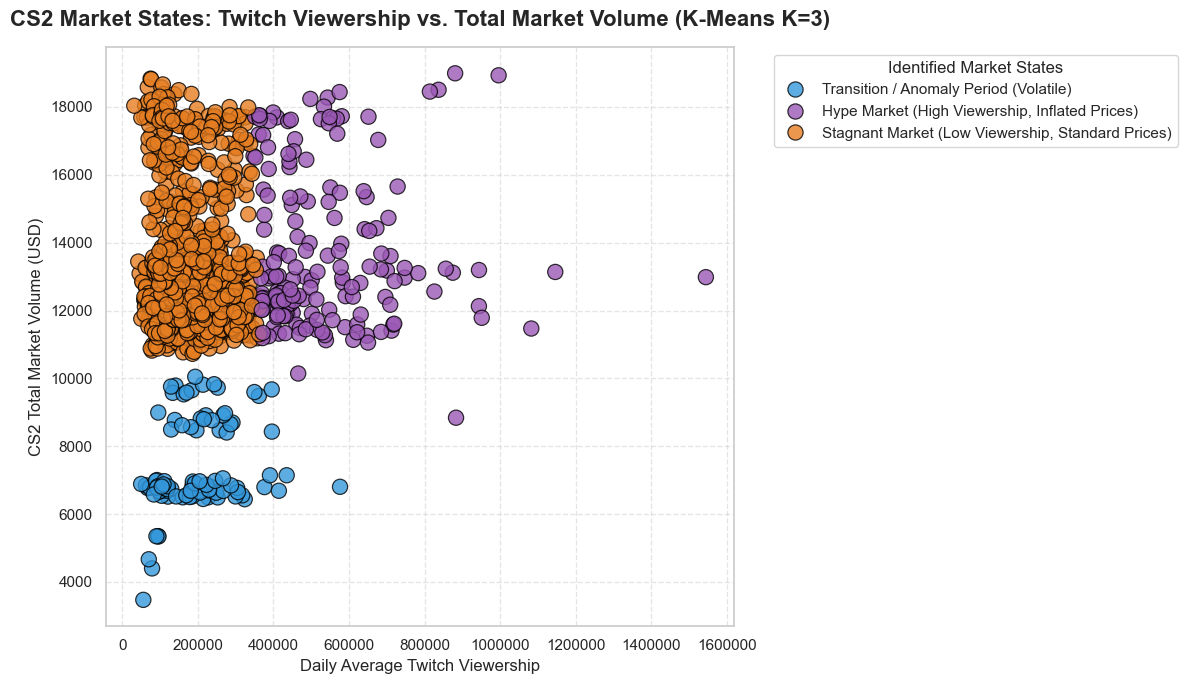


--- CLUSTER PROFILES & ANALYTICAL SUMMARY ---
[Stagnant Market (Low Activity)]
  -> Total Data Points (Days): 928
  -> Average Viewership: 178,127
  -> Average Market Value: $13,387.43

[Growth / Transition State]
  -> Total Data Points (Days): 93
  -> Average Viewership: 198,724
  -> Average Market Value: $7,384.31

[Hype Market (Peak Demand)]
  -> Total Data Points (Days): 175
  -> Average Viewership: 537,268
  -> Average Market Value: $13,801.39



In [54]:
# ---------------------------------------------------------
# STEP 3: VISUALIZATION OF ML RESULTS
# ---------------------------------------------------------
print("3. Visualizing K-Means Clustering Results...")

plt.figure(figsize=(12, 7))

# Scatter Plot using Seaborn
sns.scatterplot(
    x='ort_izleyici', 
    y='Total_Market_Value', 
    hue='Cluster_Name', 
    palette=['#3498db', '#9b59b6', '#e67e22'],
    data=ml_df, 
    s=120, 
    alpha=0.8,
    edgecolor='black'
)

# Style the chart
plt.title('CS2 Market States: Twitch Viewership vs. Total Market Volume (K-Means K=3)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Daily Average Twitch Viewership', fontsize=12)
plt.ylabel('CS2 Total Market Volume (USD)', fontsize=12)

# Fix axis formats (Removing scientific notation)
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')

# Legend settings
plt.legend(title='Identified Market States', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save the plot
ml_plot_filename = "cs2_kmeans_market_states.png"
plt.savefig(ml_plot_filename, dpi=300, bbox_inches='tight')
print(f" ML Visualization saved as '{ml_plot_filename}'!")

plt.show()

# Analytical Output / Cluster Profiling (Terminal Output)
print("\n--- CLUSTER PROFILES & ANALYTICAL SUMMARY ---")
for cluster_id in sorted_clusters:
    subset = ml_df[ml_df['Cluster'] == cluster_id]
    avg_viewers = subset['ort_izleyici'].mean()
    avg_value = subset['Total_Market_Value'].mean()
    label = cluster_labels_map[cluster_id]
    
    print(f"[{label}]")
    print(f"  -> Total Data Points (Days): {len(subset)}")
    print(f"  -> Average Viewership: {avg_viewers:,.0f}")
    print(f"  -> Average Market Value: ${avg_value:,.2f}\n")

###  Milestone 2 Conclusion
The K-Means model successfully mathematically proved what our EDA suggested.
1. The **"Hype Market"** cluster demonstrates that peak viewership days definitively correlate with the highest market valuations.
2. The **"Transition State"** cluster is crucial: it shows instances where viewership might have dropped, but prices remained artificially inflated (price stickiness), validating that analyzing viewership alone is insufficient without understanding market states.
3. The positive **"Silhouette Score"** validates our feature engineering (Total Market Value) and scaling approach.